# GRB clustering

Discover clustering methods and conclude with some observation about Gamma-Ray-Bust.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.cluster import KMeans, MeanShift
from sklearn import preprocessing
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import confusion_matrix, classification_report

In [3]:
load = np.loadtxt("Summary_GRB.txt", dtype='str',unpack='True')

### Warm up

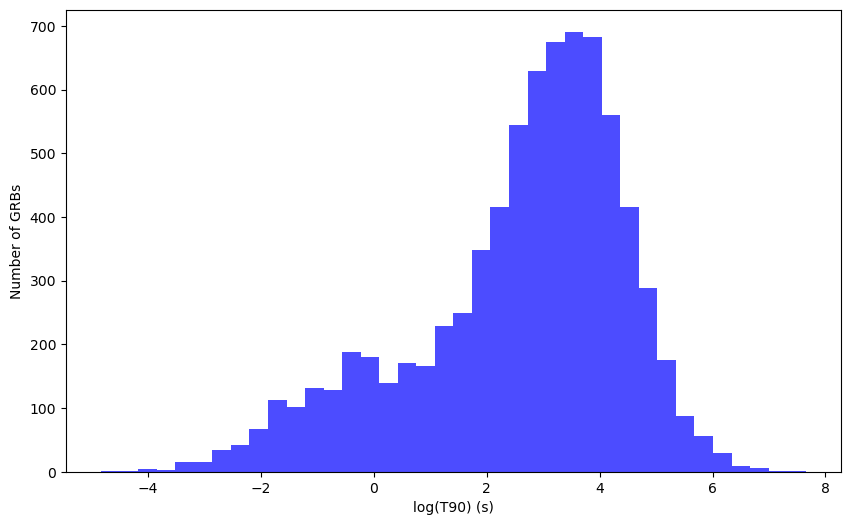

In [4]:
T90 = np.array(load[6], dtype=float)
mask = (T90 > 0)
T90 = T90[mask]

plt.figure(figsize=(10, 6))
plt.hist(np.log(T90), bins='scott', color='blue', alpha=0.7)
plt.xlabel('log(T90) (s)')
plt.ylabel('Number of GRBs')
plt.show()

Preprocessig is needed to make work the distance that minimize in the loss function of K-mean.

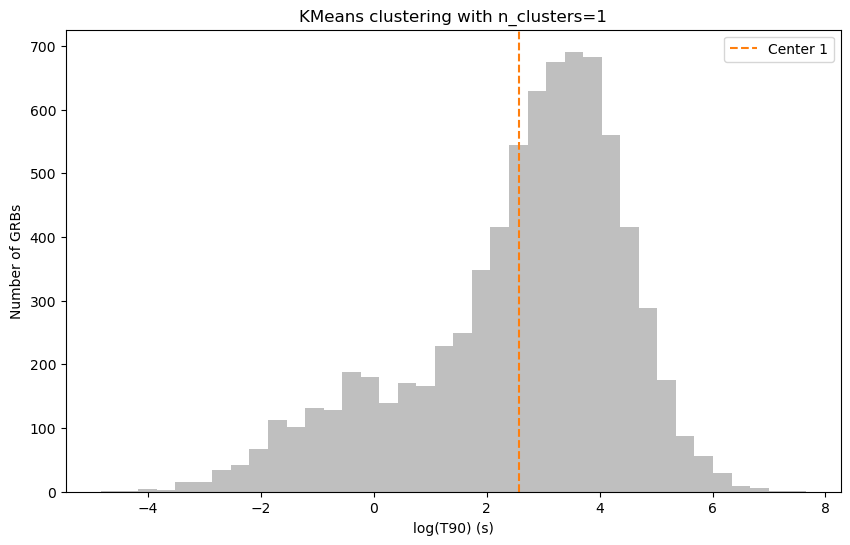

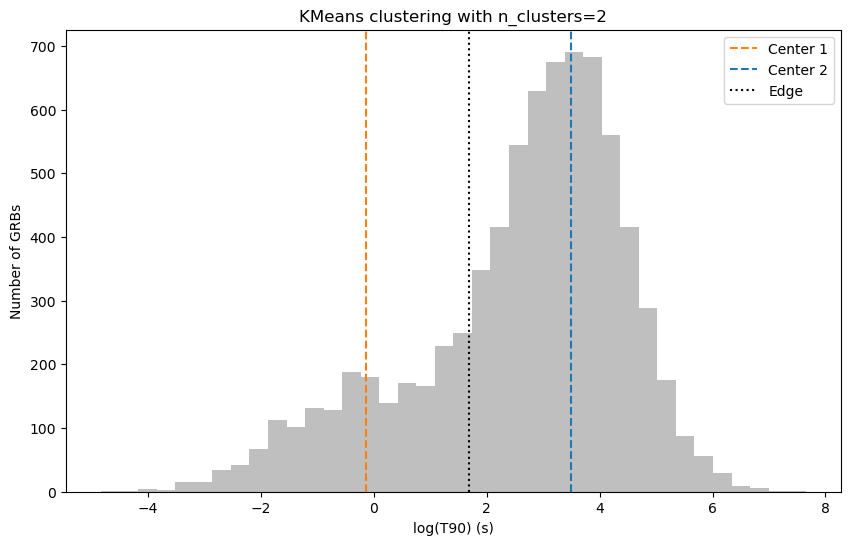

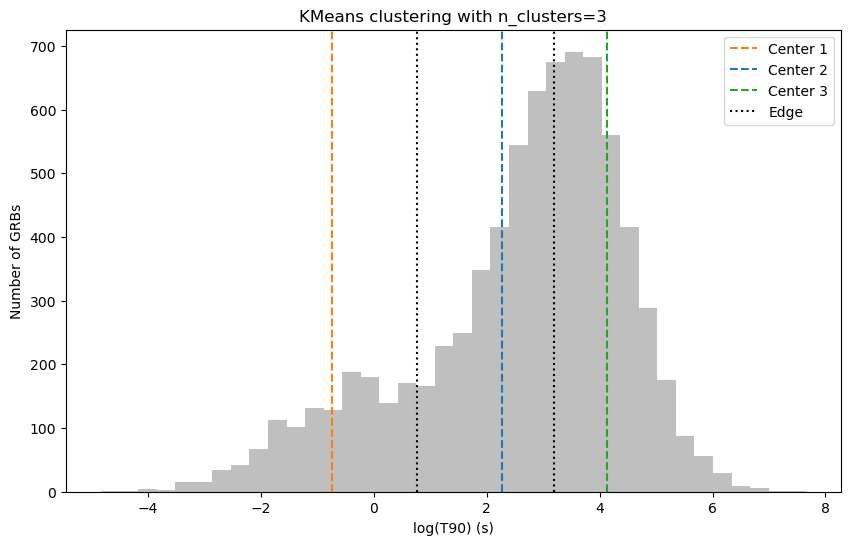

In [5]:
scaler = preprocessing.StandardScaler()

X = np.log(T90).reshape(-1, 1)
X = scaler.fit_transform(X)
colors = ['C1', 'C0', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']

for n in range(1, 4):
    clKM = KMeans(n_clusters=n, random_state=1234, n_init='auto')
    labels = clKM.fit_predict(X)
    centers = scaler.inverse_transform(clKM.cluster_centers_).ravel()
    centers = np.sort(centers)

    plt.figure(figsize=(10, 6))
    plt.hist(scaler.inverse_transform(X), bins='scott', color='gray', alpha=0.5)
    for i in enumerate(centers):
        plt.axvline(x=i[1], color=colors[i[0]], linestyle='--', label=f'Center {i[0]+1}')
    if n > 1:
        edges = (centers[:-1] + centers[1:]) / 2
        for edge_idx, edge in enumerate(edges):
            plt.axvline(x=edge, color='black', linestyle=':', linewidth=1.5, label='Edge' if edge_idx == 0 else None)

    plt.xlabel('log(T90) (s)')
    plt.ylabel('Number of GRBs')
    plt.title(f'KMeans clustering with n_clusters={n}')
    plt.legend()
    plt.show()

### More features

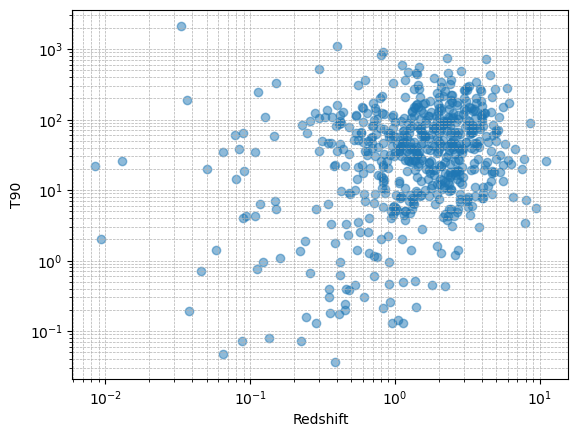

In [6]:
redshift = np.array(load[11], dtype=float)
T90 = np.array(load[6], dtype=float)

mask = (redshift > 0) & (T90 > 0)

plt.scatter(redshift[mask], T90[mask], alpha=0.5)
plt.xlabel('Redshift')
plt.ylabel('T90')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.show()


In [7]:
nclusters = 5
data = np.column_stack((redshift[mask], T90[mask]))
data_log = np.log(data)
data_scaled = scaler.fit_transform(data_log)

In [8]:
clKM = KMeans(n_clusters=nclusters, n_init='auto')
clKM.fit(data_scaled)

KMeans(n_clusters=5)

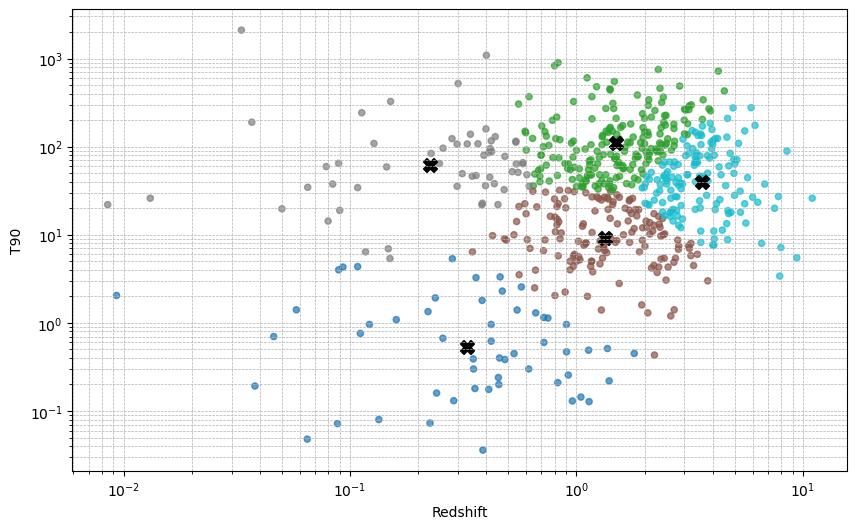

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(data[:, 0], data[:, 1], c=clKM.labels_, cmap='tab10', s=20, alpha=0.7)
plt.scatter(np.exp(scaler.inverse_transform(clKM.cluster_centers_)[:, 0]), np.exp(scaler.inverse_transform(clKM.cluster_centers_)[:, 1]), c='black', s=100, marker='X', label='Cluster Centers')
plt.xlabel('Redshift')
plt.ylabel('T90')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)


In [10]:
clMS = MeanShift(bandwidth=1.0)
clMS.fit(data_scaled)

MeanShift(bandwidth=1.0)

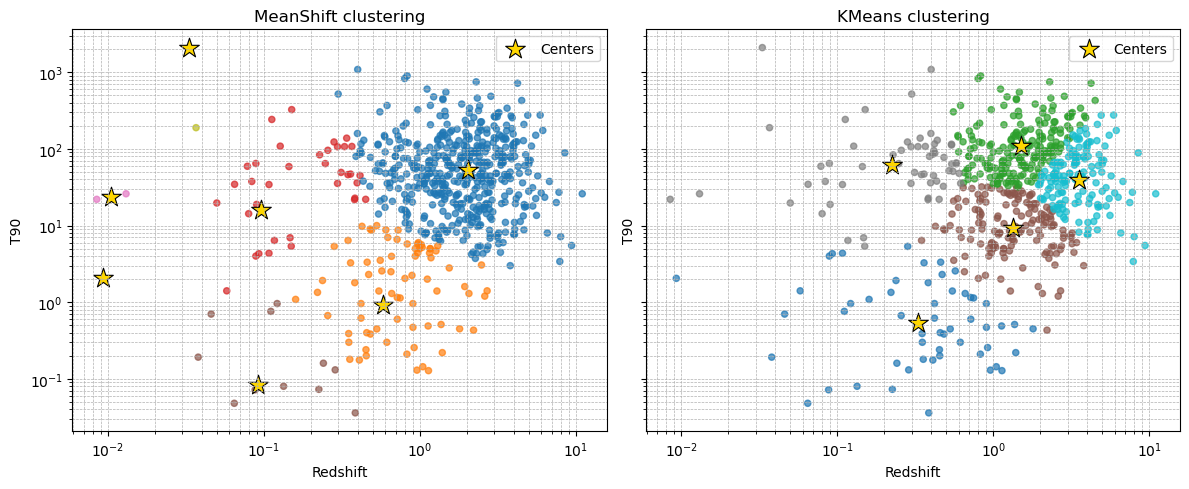

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(data[:, 0], data[:, 1], c=clMS.labels_, cmap='tab10', s=20, alpha=0.7)
axes[0].set_title('MeanShift clustering')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('T90')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

axes[1].scatter(data[:, 0], data[:, 1], c=clKM.labels_, cmap='tab10', s=20, alpha=0.7)
axes[1].set_title('KMeans clustering')
axes[1].set_xlabel('Redshift')
axes[1].set_ylabel('T90')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

centersKM = np.exp(scaler.inverse_transform(clKM.cluster_centers_))
centersMS = np.exp(scaler.inverse_transform(clMS.cluster_centers_))

axes[0].scatter(
    centersMS[:, 0], centersMS[:, 1],
    marker='*', s=220, c='gold', edgecolors='black', linewidths=0.8, label='Centers'
)
axes[1].scatter(
    centersKM[:, 0], centersKM[:, 1],
    marker='*', s=220, c='gold', edgecolors='black', linewidths=0.8, label='Centers'
)

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

**Comment:**

- It's an unsupervised learning: we are sensible on number of cluster wich we can fix with cross validation. Comparison beetween the two method is difficult because of different loss function; there are still method probabily in the licterature, plus we can use some euritstic metric to do so.

- MeanShift is very sensible to bandwith input.

- When we have a single point cluster could we interprete this as outliers, or rare event.

### Cross validation & Clustering

Let's use the scikit library to compare different clustering models. Since clustering is an unsupervised learning task, we need a metric to evaluate the quality of the results.

One of the most common metrics is the **Silhouette Score**, defined as


$$ s_i = \frac{b_i - a_i}{\max(a_i, b_i)} $$


where

- $a_i$ is the average distance between sample i and the other points in the same cluster;
- $b_i$ is the average distance between sample i and the nearest different cluster.

A good clustering minimizes $a_i$ and maximizes $b_i$. The Silhouette Score ranges from −1 to 1, where values close to 1 indicate better clustering.

In [19]:
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV

In [20]:
def silhouette_scorer(estimator, data):
    labels = estimator.predict(data)

    if len(set(labels)) < 2:
        return -1  
    return silhouette_score(data, labels)

In [26]:
km = KMeans(n_init='auto')
ms = MeanShift()

grid_params_km = {
    "n_clusters": [2, 3, 4, 5, 6, 7, 8, 9, 10]
}

grid_params_ms = {
    "bandwidth": np.linspace(0.1, 2.0, 20)
}

In [27]:
grid_km = GridSearchCV(km, grid_params_km, scoring=silhouette_scorer, cv=5)
grid_km.fit(data_scaled)

GridSearchCV(cv=5, estimator=KMeans(),
             param_grid={'n_clusters': [2, 3, 4, 5, 6, 7, 8, 9, 10]},
             scoring=<function silhouette_scorer at 0x15e107100>)

In [28]:
grid_ms = GridSearchCV(ms, grid_params_ms, scoring=silhouette_scorer, cv=5)
grid_ms.fit(data_scaled)
grid_ms.best_score_

0.5565285940892544

In [29]:
clKM_best = grid_km.best_estimator_
clKM.fit(data_scaled)

clMS_best = grid_ms.best_estimator_
clMS.fit(data_scaled)

labels_km_best = clKM_best.labels_
labels_ms_best = clMS_best.labels_

centersKM_best = np.exp(scaler.inverse_transform(clKM_best.cluster_centers_))
centersMS_best = np.exp(scaler.inverse_transform(clMS_best.cluster_centers_))

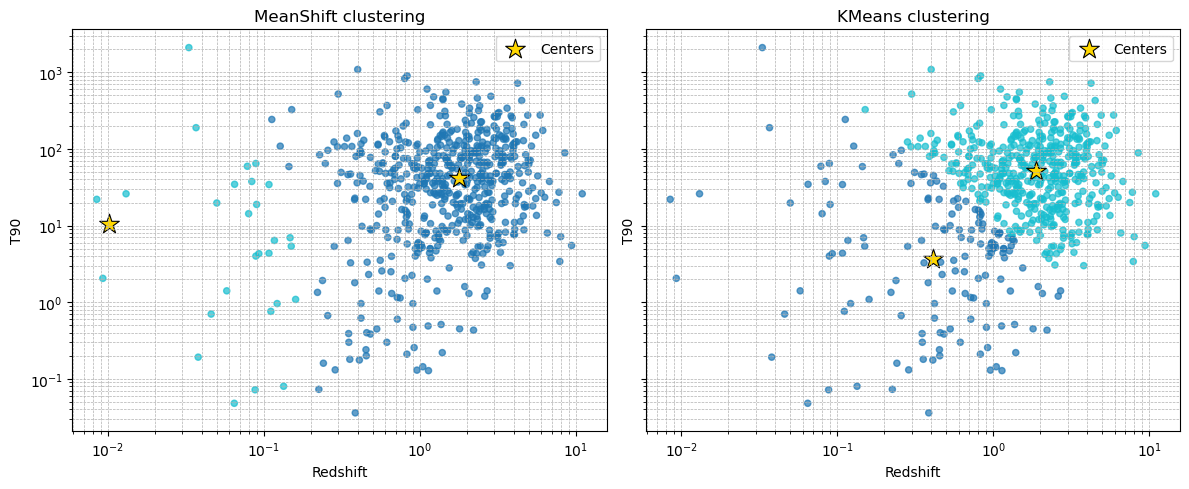

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].scatter(data[:, 0], data[:, 1], c=labels_ms_best, cmap='tab10', s=20, alpha=0.7)
axes[0].set_title('MeanShift clustering')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('T90')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, which='both', linestyle='--', linewidth=0.5)

axes[1].scatter(data[:, 0], data[:, 1], c=labels_km_best, cmap='tab10', s=20, alpha=0.7)
axes[1].set_title('KMeans clustering')
axes[1].set_xlabel('Redshift')
axes[1].set_ylabel('T90')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, which='both', linestyle='--', linewidth=0.5)

axes[0].scatter(
    centersMS_best[:, 0], centersMS_best[:, 1],
    marker='*', s=220, c='gold', edgecolors='black', linewidths=0.8, label='Centers'
)
axes[1].scatter(
    centersKM_best[:, 0], centersKM_best[:, 1],
    marker='*', s=220, c='gold', edgecolors='black', linewidths=0.8, label='Centers'
)

axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()